# Activity inference in video – Reproduction des algorithmes

Ce notebook implémente, sous forme modulaire et commentée, l'ensemble des algorithmes décrits dans le rapport *Activity inference in video* (Aurélien Louis, 2004).

## 1. Préliminaires et dépendances

In [13]:
import numpy as np
import scipy as sp
import scipy.spatial
import scipy.optimize
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.sparse.linalg import eigsh

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from tqdm import tqdm
from sklearn.datasets import fetch_openml

## 2. Extraction des contours et points de contrôle (Section 2.2.1)

In [5]:

def extract_edges(image, low=100, high=200):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.Canny(gray, low, high)


def sample_contour_points(edges, n_points=100):
    ys, xs = np.where(edges > 0)
    if len(xs) == 0:
        return np.empty((0, 2))
    idx = np.linspace(0, len(xs) - 1, n_points).astype(int)
    return np.stack([xs[idx], ys[idx]], axis=1)

## 3. Shape Contexts (Sections 2.2.2–2.2.3)

In [6]:

def shape_context(points, n_r=5, n_theta=12):
    dists = sp.spatial.distance.cdist(points, points)
    mean_dist = dists.mean()
    dists /= mean_dist
    angles = np.arctan2(points[:, None, 1] - points[None, :, 1],
                        points[:, None, 0] - points[None, :, 0])

    r_bins = np.logspace(-1, 1, n_r)
    t_bins = np.linspace(-np.pi, np.pi, n_theta + 1)
    contexts = []

    for i in range(len(points)):
        hist = np.zeros((n_r, n_theta))
        for j in range(len(points)):
            if i == j:
                continue
            r = dists[i, j]
            t = angles[i, j]
            rb = np.searchsorted(r_bins, r) - 1
            tb = np.searchsorted(t_bins, t) - 1
            if 0 <= rb < n_r and 0 <= tb < n_theta:
                hist[rb, tb] += 1
        hist /= hist.sum() + 1e-8
        contexts.append(hist.flatten())
    return np.array(contexts)


def chi2_cost(h1, h2):
    return 0.5 * np.sum((h1 - h2)**2 / (h1 + h2 + 1e-8))


## 4. Appariement optimal – Algorithme hongrois (2.2.3)

In [7]:

def matching_cost(ctx1, ctx2):
    C = np.zeros((len(ctx1), len(ctx2)))
    for i in range(len(ctx1)):
        for j in range(len(ctx2)):
            C[i, j] = chi2_cost(ctx1[i], ctx2[j])
    return C


def hungarian_matching(C):
    r, c = sp.optimize.linear_sum_assignment(C)
    return list(zip(r, c))


## 5. Distance entre formes (Section 2.2.5)

In [8]:

def shape_distance(cost_matrix, matching):
    return np.mean([cost_matrix[i, j] for i, j in matching])


## 6. Embedding spectral (Sections 1.3.1–1.3.4)

In [9]:

def spectral_embedding(W, n_dims=6):
    D = np.diag(W.sum(axis=1))
    L = D - W
    vals, vecs = eigsh(L, k=n_dims + 1, M=D, which='SM')
    return vecs[:, 1:n_dims+1]


## 7. Clustering final des activités

In [10]:

def cluster_embedding(X, K):
    return KMeans(n_clusters=K).fit_predict(X)


## Tests du notebook
Tout d'abord, charger MNIST

In [14]:
def load_mnist(n_train=300, n_test=100, random_state=0):
    mnist = fetch_openml("mnist_784", version=1, as_frame=False)
    X = mnist.data.reshape(-1, 28, 28).astype(np.uint8)
    y = mnist.target.astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=n_train, test_size=n_test,
        stratify=y, random_state=random_state
    )
    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = load_mnist()


Détecter les contours et déterminer les points de contrôle

In [15]:
def image_to_points(img, n_points=100):
    edges = cv2.Canny(img, 80, 160)
    ys, xs = np.where(edges > 0)

    if len(xs) < n_points:
        return None  # rejet image trop pauvre

    idx = np.linspace(0, len(xs) - 1, n_points).astype(int)
    points = np.stack([xs[idx], ys[idx]], axis=1)
    return points


In [17]:
def build_shapes(X):
    shapes = []
    for img in tqdm(X):
        pts = image_to_points(img)
        shapes.append(pts)
    return shapes

train_shapes = build_shapes(X_train)
test_shapes  = build_shapes(X_test)

100%|██████████| 100/100 [00:00<00:00, 17638.69it/s]


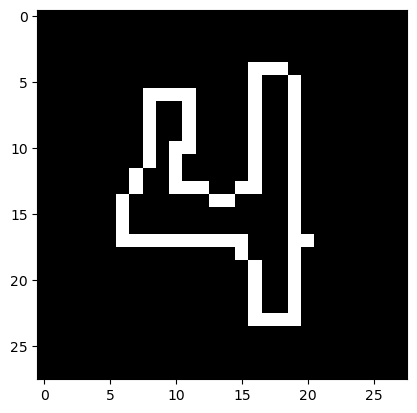

In [26]:
plt.imshow(cv2.Canny(X_train[0],80,160), cmap='gray')
plt.show()

Calcul du contexte

In [33]:
def compute_shape_contexts(shapes):
    contexts = []
    for pts in tqdm(shapes):
        if pts is None:
            contexts.append(None)
        else:
            contexts.append(shape_context(pts))
    return contexts


train_ctx = compute_shape_contexts(train_shapes)
test_ctx  = compute_shape_contexts(test_shapes)


100%|██████████| 100/100 [00:00<00:00, 110.73it/s]


In [34]:
def shape_context_distance(ctx1, ctx2):
    if ctx1 is None or ctx2 is None:
        return np.inf

    C = matching_cost(ctx1, ctx2)
    matching = hungarian_matching(C)
    return shape_distance(C, matching)
